<a href="https://colab.research.google.com/github/pokexpert/ds_4002_project3/blob/main/Scripts/flower_classification_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import + setup

import os, zipfile, urllib.request, time, copy, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from scipy.io import loadmat
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# reproduce
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)



In [ ]:

ZIP_PATH = "/content/jpg.zip"
DATA_DIR = "/content/flower_data"
IMG_DIR  = os.path.join(DATA_DIR, "jpg")

# unzip images
if not os.path.isdir(IMG_DIR):
    print("Unzipping images...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    # count only .jpg files
    jpg_count = len([f for f in os.listdir(IMG_DIR) if f.endswith('.jpg')])
    print(f"Done — {jpg_count} images extracted.")
else:
    jpg_count = len([f for f in os.listdir(IMG_DIR) if f.endswith('.jpg')])
    print(f"Images already extracted — {jpg_count} files found.")

# download label .mat file from Oxford VGG
MAT_DIR = os.path.join(DATA_DIR, "meta")
os.makedirs(MAT_DIR, exist_ok=True)

BASE_URL = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/"
for fname in ["imagelabels.mat", "setid.mat"]:
    dest = os.path.join(MAT_DIR, fname)
    if not os.path.exists(dest):
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(BASE_URL + fname, dest)
        print(f"  Saved to {dest}")

# array of length 8189, values 1-102 convert to 0-indexed
labels_mat = loadmat(os.path.join(MAT_DIR, "imagelabels.mat"))
all_labels = labels_mat["labels"].flatten() - 1  # now 0-101

# custom 80/10/10 split cuz official split only has ~1020 training images which limits model accuracy
# 80/10/10 split gives ~6,551 train images
from sklearn.model_selection import train_test_split

all_indices = np.arange(len(all_labels))

# first split 80% train 20% temp
train_ids, temp_ids = train_test_split(
    all_indices, test_size=0.20, random_state=SEED,
    stratify=all_labels
)

# second split split the 20% temp into 10% val + 10% test
temp_labels = all_labels[temp_ids]
val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.50, random_state=SEED,
    stratify=temp_labels
)

print(f"\ndataset summary:")
print(f"  total images : {len(all_labels)}")
print(f"  classes      : {len(set(all_labels))}")
print(f"  train split  : {len(train_ids)}  ({len(train_ids)/len(all_labels)*100:.1f}%)")
print(f"  val   split  : {len(val_ids)}  ({len(val_ids)/len(all_labels)*100:.1f}%)")
print(f"  test  split  : {len(test_ids)}  ({len(test_ids)/len(all_labels)*100:.1f}%)")

# verify no overlap
assert len(set(train_ids) & set(val_ids)) == 0, "Train/Val overlap"
assert len(set(train_ids) & set(test_ids)) == 0, "Train/Test overlap"
assert len(set(val_ids) & set(test_ids)) == 0, "Val/Test overlap"
assert len(train_ids) + len(val_ids) + len(test_ids) == len(all_labels)
print("\n no overlap between splits")


Unzipping images...
Done — 8189 images extracted.
  Saved to /content/flower_data/meta/imagelabels.mat
  Saved to /content/flower_data/meta/setid.mat

dataset summary:
  total images : 8189
  classes      : 102
  train split  : 6551  (80.0%)
  val   split  : 819  (10.0%)
  test  split  : 819  (10.0%)

 no overlap between splits


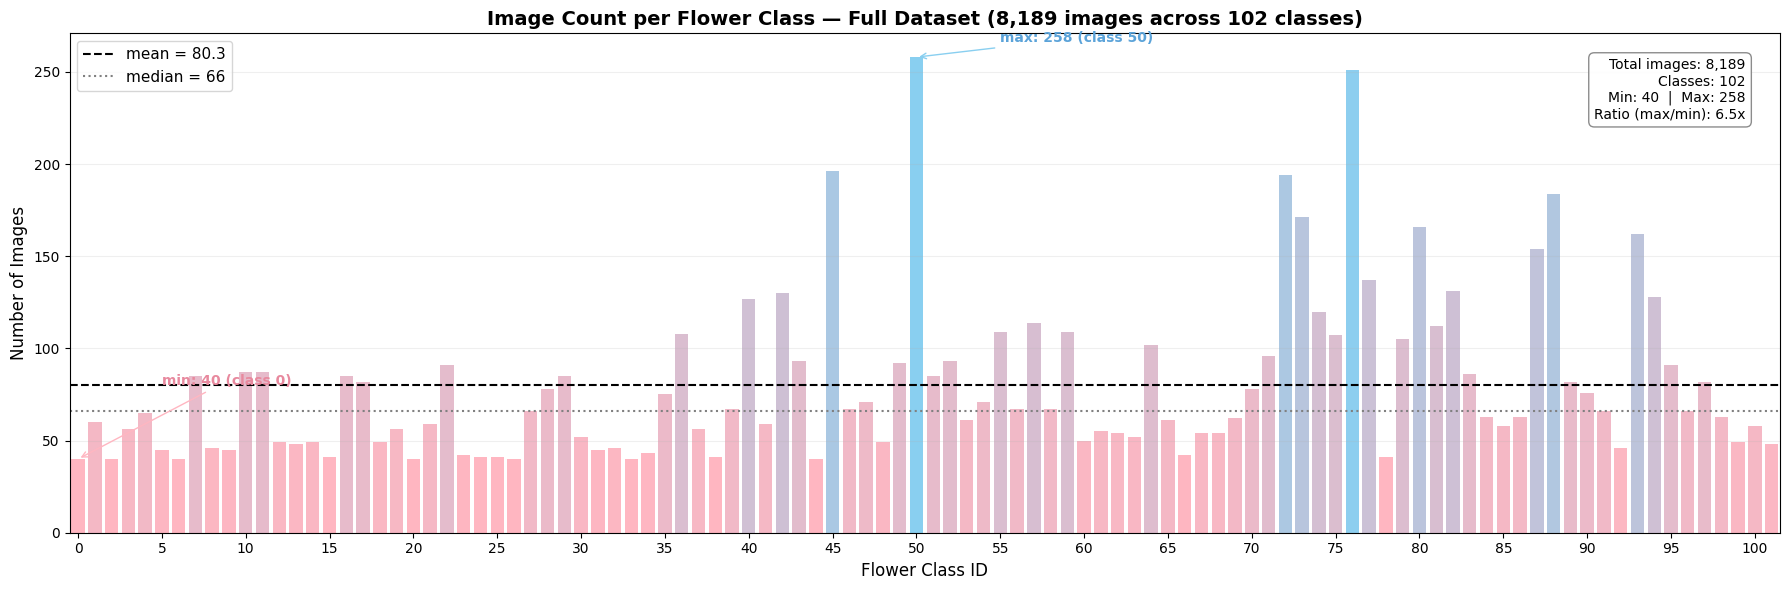

The largest class has 6.5x more images than the smallest.
This imbalance means the model may perform worse on under-represented classes.


In [ ]:
# EDA number of images per flower class
# bars in class order 0–101 pink to blue gradient

from matplotlib.colors import LinearSegmentedColormap

class_counts = Counter(all_labels)
counts = [class_counts[c] for c in range(102)]

fig, ax = plt.subplots(figsize=(18, 6))

# pink to blue
pink_blue = LinearSegmentedColormap.from_list(
    "pink_blue", ["#FFB6C1", "#89CFF0"]
)
norm = plt.Normalize(min(counts), max(counts))
colors = [pink_blue(norm(c)) for c in counts]

bars = ax.bar(range(102), counts, color=colors, edgecolor="none")

# reference lines
ax.axhline(y=np.mean(counts), color="black", ls="--", lw=1.5,
           label=f"mean = {np.mean(counts):.1f}")
ax.axhline(y=np.median(counts), color="gray", ls=":", lw=1.5,
           label=f"median = {np.median(counts):.0f}")

# min and max
max_class = np.argmax(counts)
min_class = np.argmin(counts)

ax.annotate(f"max: {counts[max_class]} (class {max_class})",
            xy=(max_class, counts[max_class]),
            xytext=(max_class + 5, counts[max_class] + 8),
            arrowprops=dict(arrowstyle="->", color="#89CFF0"),
            fontsize=10, color="#5BA3D9", fontweight="bold")

ax.annotate(f"min: {counts[min_class]} (class {min_class})",
            xy=(min_class, counts[min_class]),
            xytext=(min_class + 5, counts[min_class] + 40),
            arrowprops=dict(arrowstyle="->", color="#FFB6C1"),
            fontsize=10, color="#E8899E", fontweight="bold")

# x ticks every 5 classes
ax.set_xticks(range(0, 102, 5))
ax.set_xlabel("Flower Class ID", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("Image Count per Flower Class — Full Dataset (8,189 images across 102 classes)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim(-0.5, 101.5)
ax.grid(axis="y", alpha=0.2)

# summary
stats_text = (f"Total images: {sum(counts):,}\n"
              f"Classes: 102\n"
              f"Min: {min(counts)}  |  Max: {max(counts)}\n"
              f"Ratio (max/min): {max(counts)/min(counts):.1f}x")
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9))

plt.tight_layout()
plt.show()

print(f"The largest class has {max(counts)/min(counts):.1f}x more images "
      f"than the smallest.")

/tmp/ipykernel_1576/2961126967.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


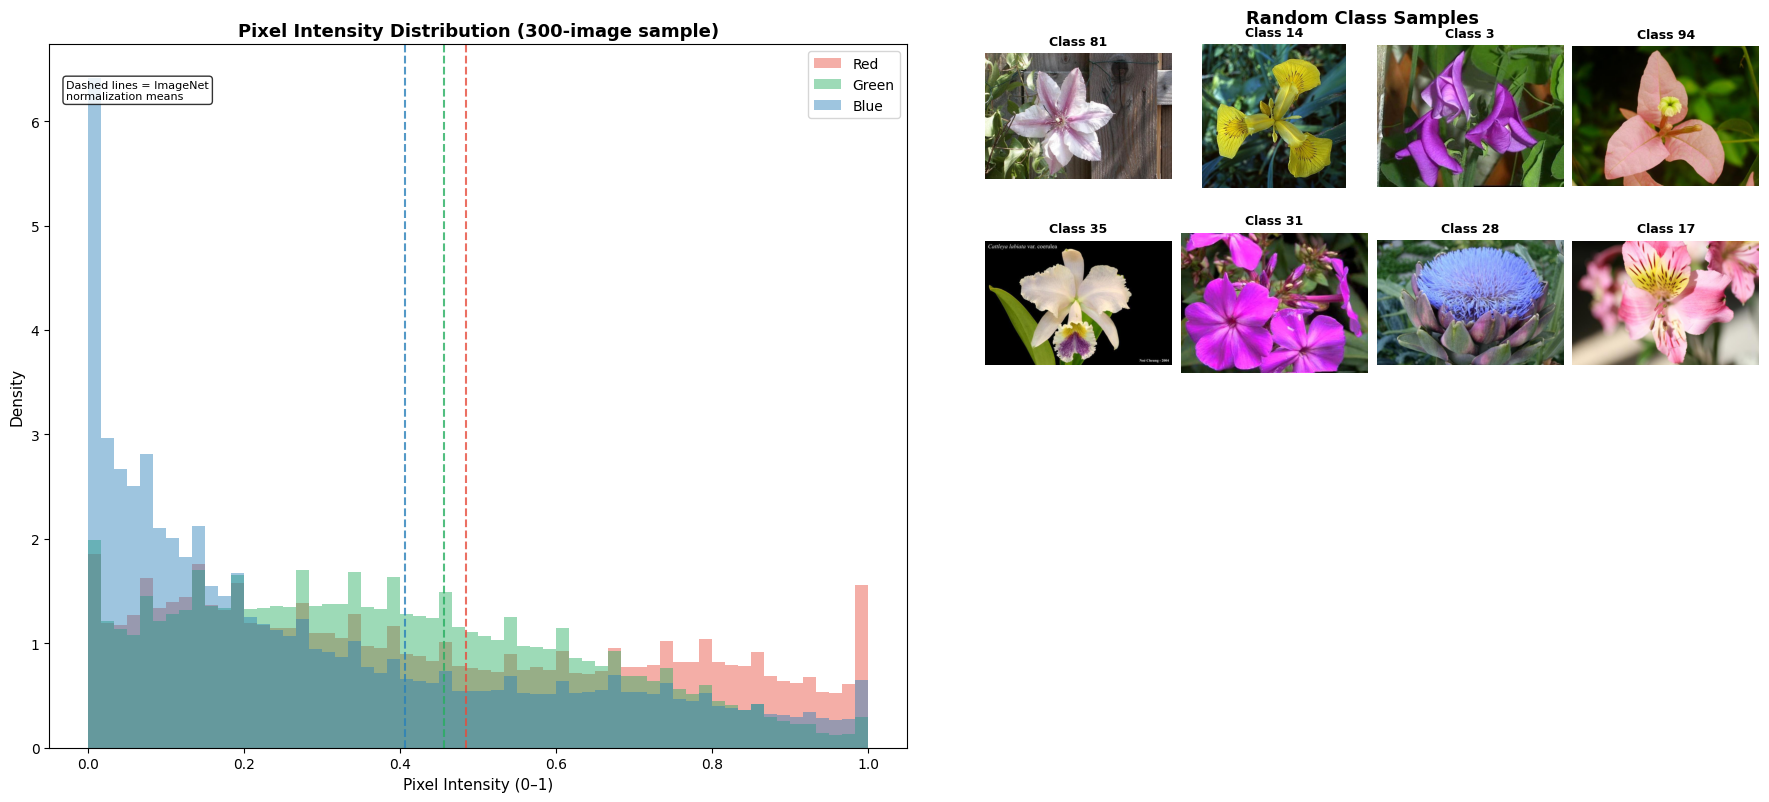

In [ ]:
# EDA per-Channel pixel intensity + visual sample grid

fig = plt.figure(figsize=(18, 8))

# left = pixel intensity histogram
ax_hist = fig.add_subplot(1, 2, 1)
# sample 300
sample_idxs = np.random.choice(len(all_labels), 300, replace=False)
all_r, all_g, all_b = [], [], []

for idx in sample_idxs:
    img = Image.open(
        os.path.join(IMG_DIR, f"image_{idx + 1:05d}.jpg")
    ).convert("RGB")
    arr = np.array(img, dtype=np.float32) / 255.0
    flat = arr.reshape(-1, 3)[::50]  # subsample pixels for efficiency
    all_r.extend(flat[:, 0])
    all_g.extend(flat[:, 1])
    all_b.extend(flat[:, 2])

ax_hist.hist(all_r, bins=60, alpha=0.45, color="#e74c3c", label="Red",   density=True)
ax_hist.hist(all_g, bins=60, alpha=0.45, color="#27ae60", label="Green", density=True)
ax_hist.hist(all_b, bins=60, alpha=0.45, color="#2980b9", label="Blue",  density=True)

# imagenet normalization means
for val, color in [(0.485, "#e74c3c"), (0.456, "#27ae60"), (0.406, "#2980b9")]:
    ax_hist.axvline(x=val, color=color, ls="--", lw=1.5, alpha=0.8)

ax_hist.set_xlabel("Pixel Intensity (0–1)", fontsize=11)
ax_hist.set_ylabel("Density", fontsize=11)
ax_hist.set_title("Pixel Intensity Distribution (300-image sample)",
                  fontsize=13, fontweight="bold")
ax_hist.legend(fontsize=10)
ax_hist.text(0.02, 0.95, "Dashed lines = ImageNet\nnormalization means",
             transform=ax_hist.transAxes, fontsize=8, va="top",
             bbox=dict(boxstyle="round", fc="white", alpha=0.8))

# sample from 8 random classes
gs = fig.add_gridspec(4, 4, left=0.55, right=0.98, hspace=0.3, wspace=0.05)
random_classes = random.sample(range(102), 8)

for grid_idx, cid in enumerate(random_classes):
    row, col = divmod(grid_idx, 4)
    ax = fig.add_subplot(gs[row, col])
    idxs = np.where(all_labels == cid)[0]
    img_idx = np.random.choice(idxs)
    img = Image.open(os.path.join(IMG_DIR, f"image_{img_idx + 1:05d}.jpg"))
    ax.imshow(img)
    ax.set_title(f"Class {cid}", fontsize=9, fontweight="bold")
    ax.axis("off")

fig.text(0.76, 0.98, "Random Class Samples", ha="center", fontsize=13,
         fontweight="bold")

plt.tight_layout()
plt.show()


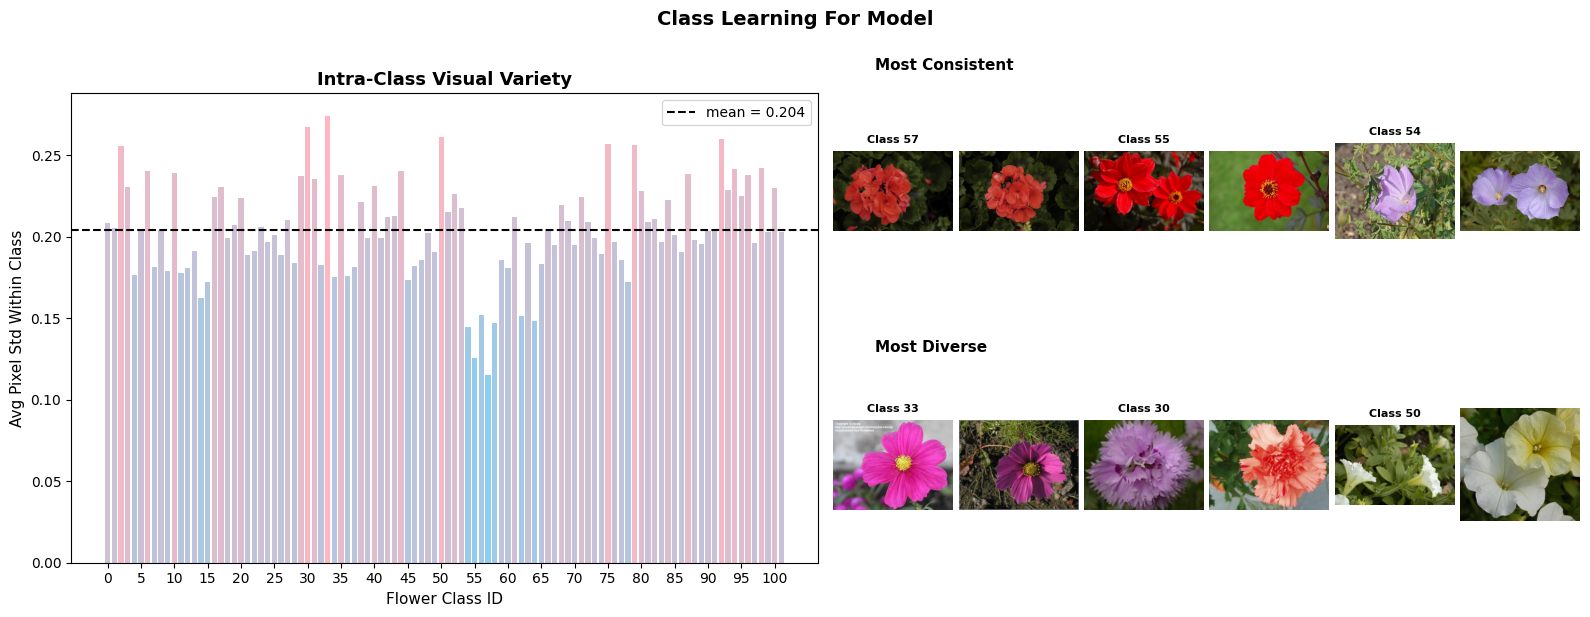

In [ ]:
# EDA intra-class visual variety how similar are the images WITHIN that class
# measured by std of pixel values across samples high std = diverse poses/angles.

class_std = {}

for cid in range(102):
    idxs = np.where(all_labels == cid)[0]
    sample = np.random.choice(idxs, min(10, len(idxs)), replace=False)
    resized_imgs = []
    for idx in sample:
        img = Image.open(
            os.path.join(IMG_DIR, f"image_{idx + 1:05d}.jpg")
        ).convert("RGB").resize((64, 64))  # small for speed
        resized_imgs.append(np.array(img, dtype=np.float32) / 255.0)
    stacked = np.stack(resized_imgs)
    class_std[cid] = stacked.std(axis=0).mean()  # avg pixel-wise std

std_vals = [class_std[c] for c in range(102)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# left = bar chart of instra class std
from matplotlib.colors import LinearSegmentedColormap
pink_blue = LinearSegmentedColormap.from_list("pb", ["#89CFF0", "#FFB6C1"])
norm = plt.Normalize(min(std_vals), max(std_vals))
bar_colors = [pink_blue(norm(v)) for v in std_vals]

axes[0].bar(range(102), std_vals, color=bar_colors, edgecolor="none")
axes[0].axhline(y=np.mean(std_vals), color="black", ls="--", lw=1.5,
                label=f"mean = {np.mean(std_vals):.3f}")
axes[0].set_xticks(range(0, 102, 5))
axes[0].set_xlabel("Flower Class ID", fontsize=11)
axes[0].set_ylabel("Avg Pixel Std Within Class", fontsize=11)
axes[0].set_title("Intra-Class Visual Variety",
                  fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)

# right = show the most consistent vs most diverse classes
most_consistent = sorted(class_std, key=class_std.get)[:3]
most_diverse    = sorted(class_std, key=class_std.get, reverse=True)[:3]

gs = axes[1].get_gridspec()
axes[1].remove()
sub_gs = gs[0, 1].subgridspec(2, 6, hspace=0.4, wspace=0.05)

for row, (label, cls_list) in enumerate([("Most Consistent", most_consistent),
                                          ("Most Diverse", most_diverse)]):
    for j, cid in enumerate(cls_list):
        idxs = np.where(all_labels == cid)[0]
        picks = np.random.choice(idxs, 2, replace=False)
        for k, idx in enumerate(picks):
            ax = fig.add_subplot(sub_gs[row, j * 2 + k])
            img = Image.open(os.path.join(IMG_DIR, f"image_{idx + 1:05d}.jpg"))
            ax.imshow(img)
            ax.axis("off")
            if k == 0:
                ax.set_title(f"Class {cid}", fontsize=8, fontweight="bold")
    fig.text(0.55, 0.92 - row * 0.47, label, fontsize=11,
             fontweight="bold", color="black")

plt.suptitle("Class Learning For Model",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# transform + custom dataset augmentation for maximum accuracy with larger training set
# more aggressive augmentation cuz not ~6.5k train image

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),    # wider zoom range
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),                   # some flowers are symmetric
    transforms.RandomRotation(30),                           # wider rotation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # small shifts
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.4, hue=0.05),        # stronger color jitter
    transforms.RandomGrayscale(p=0.05),                      # occasional grayscale
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),  # perspective warp
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),   # slight blur
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],        # ImageNet stats
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),    # cutout-style
])

# validation + test deterministic resize + center crop only
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class FlowerDataset(Dataset):
    def __init__(self, img_dir, all_labels, indices, transform=None):
        self.img_dir   = img_dir
        self.labels    = all_labels
        self.indices   = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_idx  = self.indices[idx]
        img_path = os.path.join(self.img_dir, f"image_{img_idx + 1:05d}.jpg")
        image    = Image.open(img_path).convert("RGB")
        label    = self.labels[img_idx]
        if self.transform:
            image = self.transform(image)
        return image, label


  train: 205 batches  (6551 images)
  val:   26 batches  (819 images)
  test:  26 batches  (819 images)


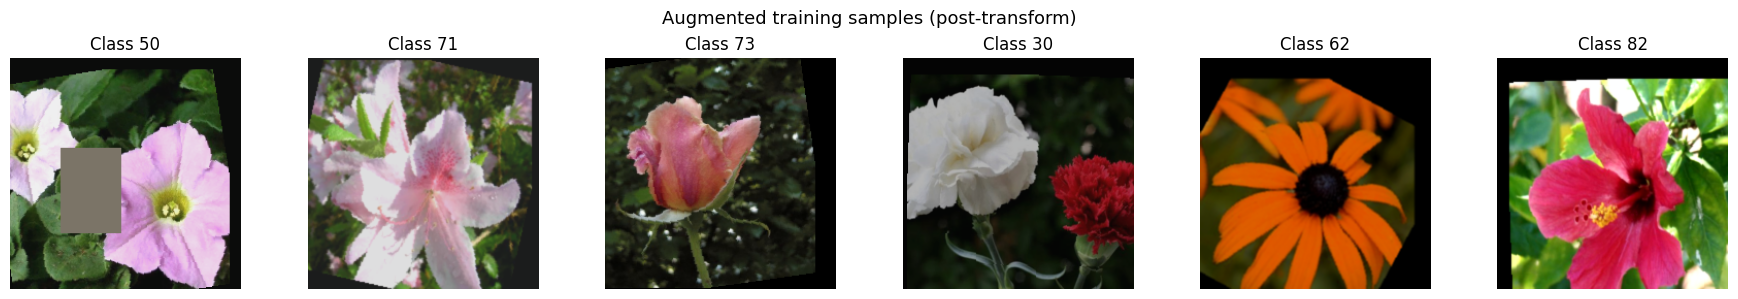

In [ ]:
# build dataloaders

BATCH_SIZE = 32

train_ds = FlowerDataset(IMG_DIR, all_labels, train_ids, train_transform)
val_ds   = FlowerDataset(IMG_DIR, all_labels, val_ids,   eval_transform)
test_ds  = FlowerDataset(IMG_DIR, all_labels, test_ids,  eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"  train: {len(train_loader)} batches  ({len(train_ds)} images)")
print(f"  val:   {len(val_loader)} batches  ({len(val_ds)} images)")
print(f"  test:  {len(test_loader)} batches  ({len(test_ds)} images)")

# visualize one augmented batch
imgs, lbls = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i, ax in enumerate(axes):
    img = imgs[i].permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f"Class {lbls[i].item()}")
    ax.axis("off")
plt.suptitle("Augmented training samples (post-transform)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# build both models freeze backbone replace class head to 102 classes

NUM_CLASSES = 102

# Define DEVICE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

def build_efficientnet_b0(num_classes=NUM_CLASSES):
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
    )
    # freeze all backbone parameters
    for param in model.parameters():
        param.requires_grad = False
    # replace classifier
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes),
    )
    return model


def build_resnet50(num_classes=NUM_CLASSES):
    model = models.resnet50(
        weights=models.ResNet50_Weights.IMAGENET1K_V1
    )
    # freeze all backbone parameters
    for param in model.parameters():
        param.requires_grad = False
    # Replace final FC layer
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# build n move to gpu
eff_model = build_efficientnet_b0().to(DEVICE)
res_model = build_resnet50().to(DEVICE)

for name, m in [("EfficientNetB0", eff_model), ("ResNet50", res_model)]:
    total, trainable = count_params(m)
    print(f"{name}:  {total:,} total params  |  {trainable:,} trainable (head only)")

Using device: cuda
EfficientNetB0:  4,138,210 total params  |  130,662 trainable (head only)
ResNet50:  23,717,030 total params  |  208,998 trainable (head only)


In [ ]:
# training function  (two-stage with early stopping)

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


def train_model(model, model_name, train_loader, val_loader,
                stage1_epochs=10, stage2_epochs=20,
                stage1_lr=1e-3, stage2_lr=1e-4, patience=5):
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [],
               "train_acc": [], "val_acc": [], "stage": []}
    best_val_acc = 0.0
    best_weights = None
    epochs_no_improve = 0

    # head only
    print(f"\n{'='*60}")
    print(f"  {model_name} — training head only ({stage1_epochs} epochs)")
    print(f"{'='*60}")

    # optimize parameters that require gradients
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=stage1_lr
    )

    for epoch in range(stage1_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["stage"].append(1)

        print(f"  epoch {epoch+1:2d}/{stage1_epochs}  "
              f"train loss: {train_loss:.4f}  acc: {train_acc:.4f}  |  "
              f"val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

    # full fine-tuning
    print(f"  {model_name} — full fine-tuning ({stage2_epochs} epochs)")

    # unfreeze all layers
    for param in model.parameters():
        param.requires_grad = True

    # differential learning rate: backbone gets 10x lower LR
    if "efficientnet" in model_name.lower():
        param_groups = [
            {"params": model.features.parameters(), "lr": stage2_lr * 0.1},
            {"params": model.classifier.parameters(), "lr": stage2_lr},
        ]
    else:
        backbone_params = [p for n, p in model.named_parameters() if "fc" not in n]
        head_params     = [p for n, p in model.named_parameters() if "fc" in n]
        param_groups = [
            {"params": backbone_params, "lr": stage2_lr * 0.1},
            {"params": head_params,     "lr": stage2_lr},
        ]

    optimizer = optim.Adam(param_groups, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )
    epochs_no_improve = 0  # reset for stage 2

    for epoch in range(stage2_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step(val_acc)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["stage"].append(2)

        print(f"  epoch {epoch+1:2d}/{stage2_epochs}  "
              f"train loss: {train_loss:.4f}  acc: {train_acc:.4f}  |  "
              f"val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  early stop ({patience} epochs with no improvement)")
                break

    # load best weights
    model.load_state_dict(best_weights)
    print(f"\n best val accuracy for {model_name}: {best_val_acc:.4f}")
    return model, history

In [ ]:
# train EfficientNetB0

t0 = time.time()
eff_model, eff_history = train_model(
    eff_model, "EfficientNetB0", train_loader, val_loader,
    stage1_epochs=10, stage2_epochs=25,
    stage1_lr=1e-3, stage2_lr=1e-4
)
eff_time = time.time() - t0
print(f"\nEfficientNetB0 total training time: {eff_time:.0f}s")


  EfficientNetB0 — training head only (10 epochs)
  epoch  1/10  train loss: 2.9831  acc: 0.4147  |  val loss: 1.6746  acc: 0.7570
  epoch  2/10  train loss: 1.5615  acc: 0.7069  |  val loss: 1.0425  acc: 0.8364
  epoch  3/10  train loss: 1.1677  acc: 0.7669  |  val loss: 0.7881  acc: 0.8596
  epoch  4/10  train loss: 0.9981  acc: 0.7817  |  val loss: 0.6580  acc: 0.8694
  epoch  5/10  train loss: 0.9023  acc: 0.7941  |  val loss: 0.5731  acc: 0.8779
  epoch  6/10  train loss: 0.8252  acc: 0.8058  |  val loss: 0.5117  acc: 0.8950
  epoch  7/10  train loss: 0.7534  acc: 0.8246  |  val loss: 0.4971  acc: 0.8913
  epoch  8/10  train loss: 0.7277  acc: 0.8199  |  val loss: 0.4595  acc: 0.8987
  epoch  9/10  train loss: 0.6934  acc: 0.8284  |  val loss: 0.4359  acc: 0.8999
  epoch 10/10  train loss: 0.6664  acc: 0.8354  |  val loss: 0.4184  acc: 0.9035
  EfficientNetB0 — full fine-tuning (25 epochs)
  epoch  1/25  train loss: 0.5589  acc: 0.8547  |  val loss: 0.3329  acc: 0.9206
  epoch  2

In [ ]:
# train ResNet50

t0 = time.time()
res_model, res_history = train_model(
    res_model, "ResNet50", train_loader, val_loader,
    stage1_epochs=10, stage2_epochs=25,
    stage1_lr=1e-3, stage2_lr=1e-4
)
res_time = time.time() - t0
print(f"\nResNet50 total training time: {res_time:.0f}s")


  ResNet50 — training head only (10 epochs)
  epoch  1/10  train loss: 2.9960  acc: 0.3680  |  val loss: 1.3445  acc: 0.7070
  epoch  2/10  train loss: 1.4001  acc: 0.6829  |  val loss: 0.8212  acc: 0.8120
  epoch  3/10  train loss: 1.0530  acc: 0.7454  |  val loss: 0.7367  acc: 0.8120
  epoch  4/10  train loss: 0.8895  acc: 0.7753  |  val loss: 0.5807  acc: 0.8462
  epoch  5/10  train loss: 0.8091  acc: 0.7880  |  val loss: 0.6142  acc: 0.8217
  epoch  6/10  train loss: 0.7416  acc: 0.8046  |  val loss: 0.5245  acc: 0.8559
  epoch  7/10  train loss: 0.7120  acc: 0.8016  |  val loss: 0.5390  acc: 0.8535
  epoch  8/10  train loss: 0.6571  acc: 0.8206  |  val loss: 0.5335  acc: 0.8498
  epoch  9/10  train loss: 0.6383  acc: 0.8226  |  val loss: 0.4961  acc: 0.8730
  epoch 10/10  train loss: 0.6118  acc: 0.8287  |  val loss: 0.4524  acc: 0.8816
  ResNet50 — full fine-tuning (25 epochs)
  epoch  1/25  train loss: 0.3749  acc: 0.8982  |  val loss: 0.3236  acc: 0.9096
  epoch  2/25  train l

In [ ]:
# test set eval (top 1 + top 5 accuracy)

def full_evaluation(model, model_name, loader):
    model.eval()
    all_preds  = []
    all_labels_list = []
    top5_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)

            # top 1
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_list.extend(labels.cpu().numpy())

            # top 5
            _, top5_preds = outputs.topk(5, dim=1)
            for i in range(labels.size(0)):
                if labels[i] in top5_preds[i]:
                    top5_correct += 1
            total += labels.size(0)

    top1_acc = np.mean(np.array(all_preds) == np.array(all_labels_list))
    top5_acc = top5_correct / total

    print(f"  {model_name} — test set results")
    print(f"  top-1 accuracy: {top1_acc:.4f}  ({top1_acc*100:.1f}%)")
    print(f"  top-5 accuracy: {top5_acc:.4f}  ({top5_acc*100:.1f}%)")

    return np.array(all_preds), np.array(all_labels_list), top1_acc, top5_acc


eff_preds, eff_test_labels, eff_top1, eff_top5 = full_evaluation(
    eff_model, "EfficientNetB0", test_loader
)
res_preds, res_test_labels, res_top1, res_top5 = full_evaluation(
    res_model, "ResNet50", test_loader
)

  EfficientNetB0 — test set results
  top-1 accuracy: 0.9646  (96.5%)
  top-5 accuracy: 0.9963  (99.6%)
  ResNet50 — test set results
  top-1 accuracy: 0.9744  (97.4%)
  top-5 accuracy: 0.9976  (99.8%)


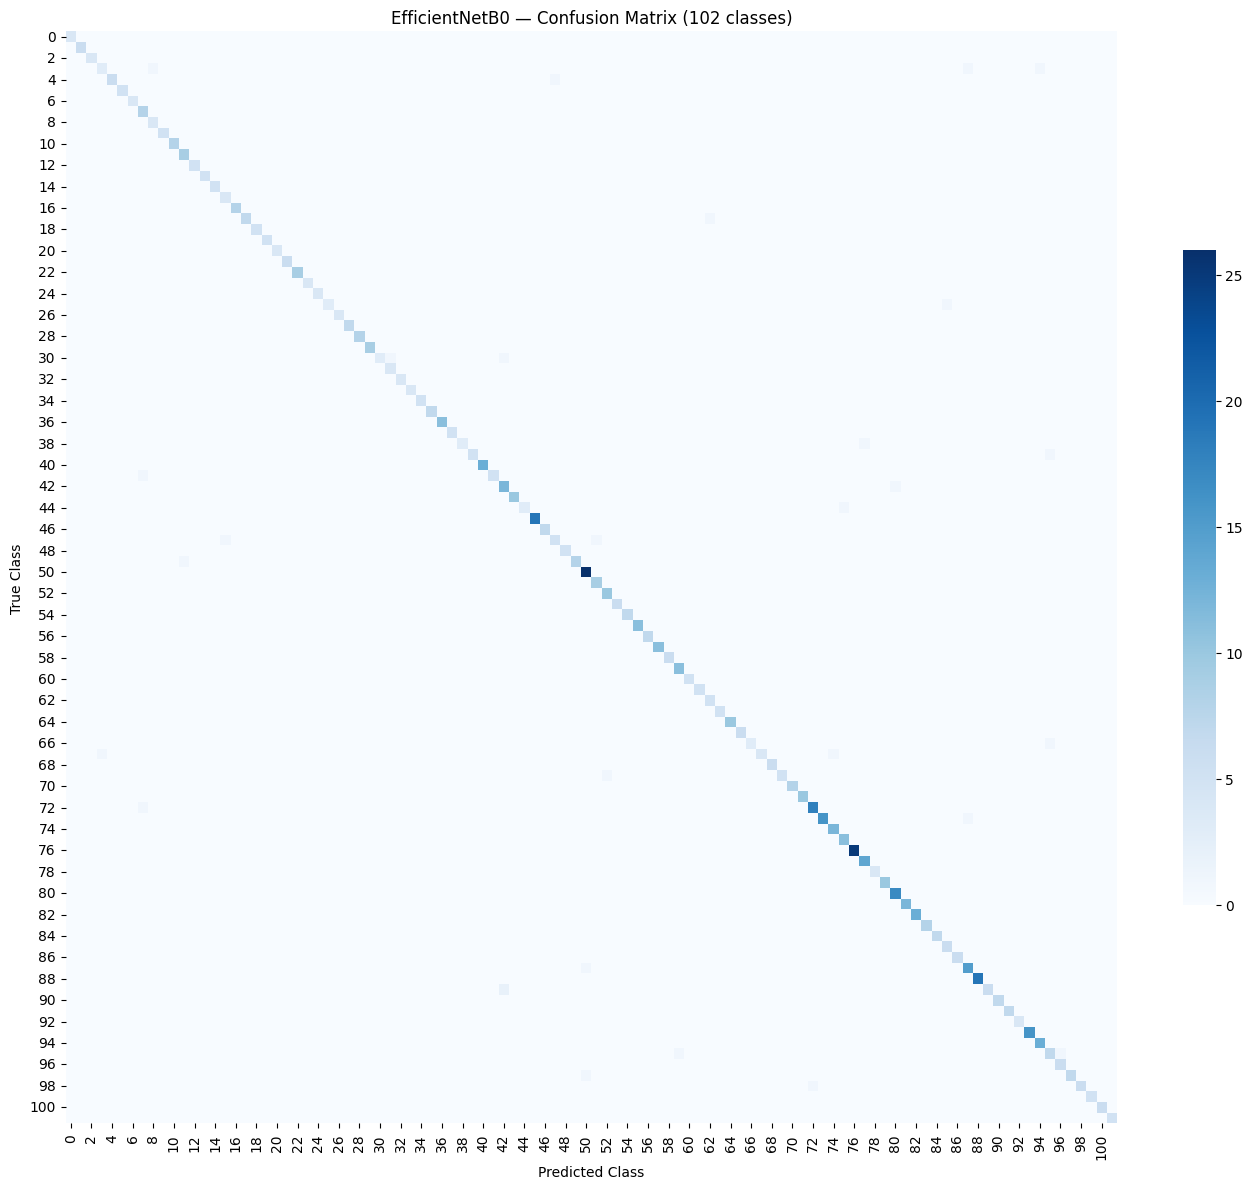


  Top-5 most confused pairs for EfficientNetB0:
    True class  44 → Predicted as  75  (1 times)
    True class  73 → Predicted as  87  (1 times)
    True class  49 → Predicted as  11  (1 times)
    True class  30 → Predicted as  42  (1 times)
    True class  89 → Predicted as  42  (2 times)


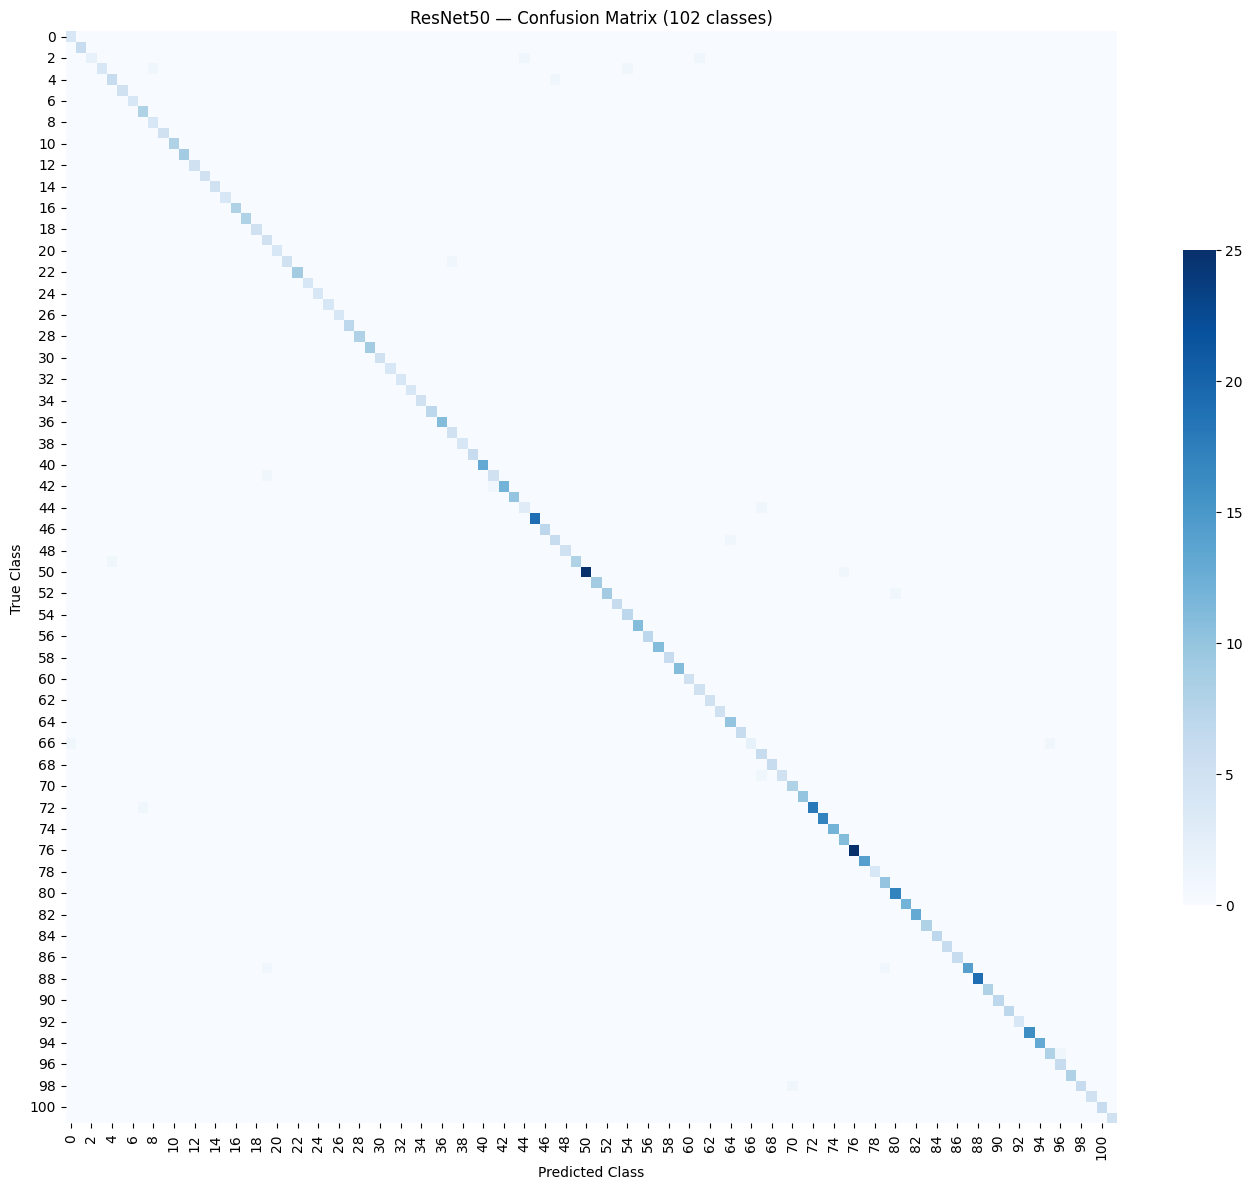


  Top-5 most confused pairs for ResNet50:
    True class  42 → Predicted as  41  (1 times)
    True class  21 → Predicted as  37  (1 times)
    True class   2 → Predicted as  61  (1 times)
    True class  66 → Predicted as   0  (1 times)
    True class   2 → Predicted as  44  (1 times)


In [ ]:
# confusion matrix

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm, cmap="Blues", ax=ax, cbar_kws={"shrink": 0.6})
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.set_title(f"{model_name} — Confusion Matrix (102 classes)")
    plt.tight_layout()
    plt.show()

    # most confused class pairs
    np.fill_diagonal(cm, 0)  # ignore correct predictions
    worst = np.unravel_index(np.argsort(cm.ravel())[-5:], cm.shape)
    print(f"\n  Top-5 most confused pairs for {model_name}:")
    for true_c, pred_c in zip(worst[0], worst[1]):
        print(f"    True class {true_c:3d} → Predicted as {pred_c:3d}  "
              f"({cm[true_c, pred_c]} times)")


# y_true first, y_pred second
plot_confusion_matrix(eff_test_labels, eff_preds, "EfficientNetB0")
plot_confusion_matrix(res_test_labels, res_preds, "ResNet50")


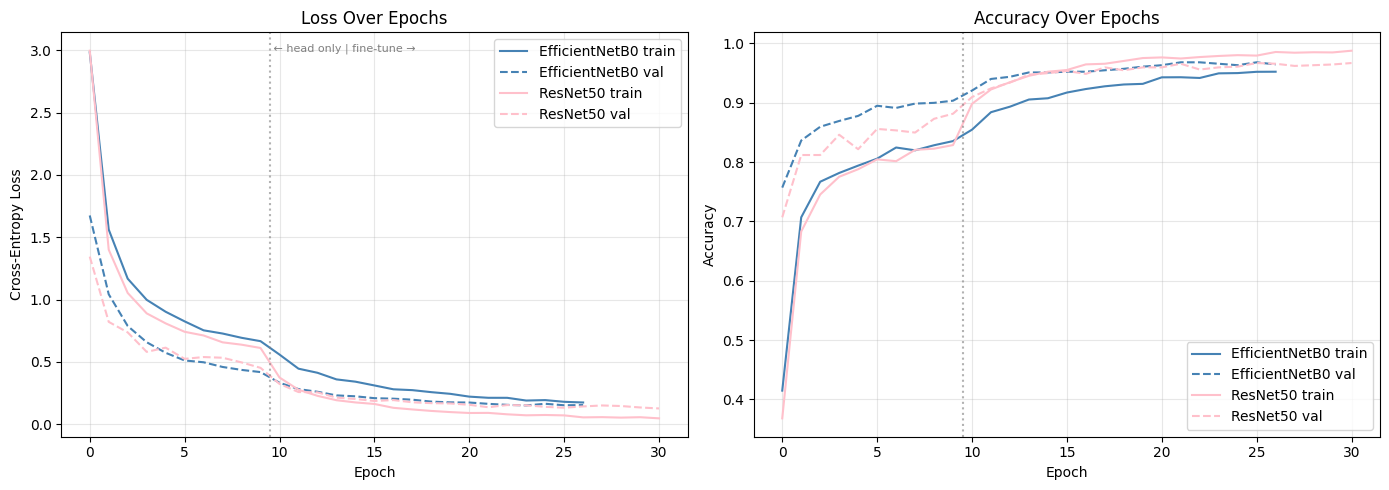

In [ ]:
# training curve (loss & accuracy side by side)

def plot_training_history(hist1, name1, hist2, name2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # loss
    axes[0].plot(hist1["train_loss"], label=f"{name1} train", color="steelblue")
    axes[0].plot(hist1["val_loss"],   label=f"{name1} val",   color="steelblue", ls="--")
    axes[0].plot(hist2["train_loss"], label=f"{name2} train", color="pink")
    axes[0].plot(hist2["val_loss"],   label=f"{name2} val",   color="pink", ls="--")
    axes[0].set_title("Loss Over Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # boundary line
    stage1_len = sum(1 for s in hist1["stage"] if s == 1)
    axes[0].axvline(x=stage1_len - 0.5, color="gray", ls=":", alpha=0.6)
    axes[0].text(stage1_len - 0.5, axes[0].get_ylim()[1] * 0.95,
                 " ← head only | fine-tune →", fontsize=8, color="gray")

    # accuracy
    axes[1].plot(hist1["train_acc"], label=f"{name1} train", color="steelblue")
    axes[1].plot(hist1["val_acc"],   label=f"{name1} val",   color="steelblue", ls="--")
    axes[1].plot(hist2["train_acc"], label=f"{name2} train", color="pink")
    axes[1].plot(hist2["val_acc"],   label=f"{name2} val",   color="pink", ls="--")
    axes[1].set_title("Accuracy Over Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].axvline(x=stage1_len - 0.5, color="gray", ls=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


plot_training_history(eff_history, "EfficientNetB0", res_history, "ResNet50")

  Final Model Comparison
Metric                     EfficientNetB0        ResNet50
Top-1 Accuracy                     96.5%          97.4%
Top-5 Accuracy                     99.6%          99.8%
Training Time                      1501s          1710s
Total Parameters                4,138,210      23,717,030

 top 5 Accuracy: ResNet50

sample test predictions:


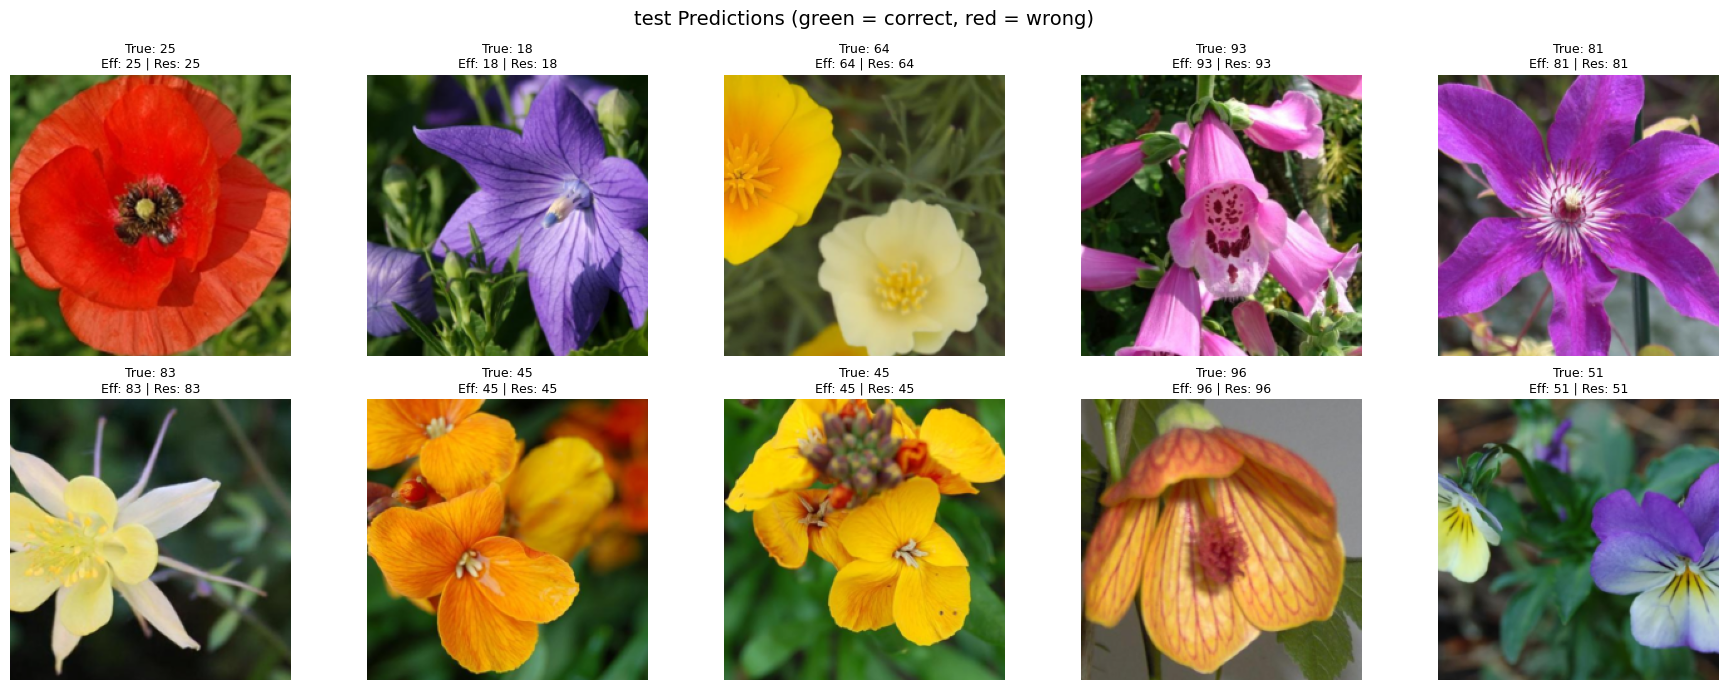

In [ ]:
# final comparison table + sample predictions

print("  Final Model Comparison")
print(f"{'Metric':<25} {'EfficientNetB0':>15} {'ResNet50':>15}")
print(f"{'Top-1 Accuracy':<25} {eff_top1:>14.1%} {res_top1:>14.1%}")
print(f"{'Top-5 Accuracy':<25} {eff_top5:>14.1%} {res_top5:>14.1%}")
print(f"{'Training Time':<25} {eff_time:>13.0f}s {res_time:>13.0f}s")
eff_total, _ = count_params(eff_model)
res_total, _ = count_params(res_model)
print(f"{'Total Parameters':<25} {eff_total:>15,} {res_total:>15,}")

winner = "EfficientNetB0" if eff_top5 >= res_top5 else "ResNet50"
print(f"\n top 5 Accuracy: {winner}")

# sample test pred w images
print("\nsample test predictions:")
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
sample_indices = np.random.choice(len(test_ds), 10, replace=False)

for i, ax in enumerate(axes.flat):
    img, true_label = test_ds[sample_indices[i]]
    display = img.permute(1, 2, 0).numpy()
    display = display * np.array([0.229, 0.224, 0.225]) + \
              np.array([0.485, 0.456, 0.406])
    display = np.clip(display, 0, 1)
    ax.imshow(display)

    e_pred = eff_preds[sample_indices[i]]
    r_pred = res_preds[sample_indices[i]]
    ax.set_title(f"True: {true_label}\nEff: {e_pred} | Res: {r_pred}",
                 fontsize=9)
    ax.axis("off")

plt.suptitle("test Predictions (green = correct, red = wrong)", fontsize=14)
plt.tight_layout()
plt.show()
